# 🌐 Clusterização com DBSCAN na prática

### Density-Based Spatial Clustering of Applications with Noise

---

> 📌 **Aula anterior:** vimos o **K-Means** — particiona o espaço em `k` clusters esféricos a partir de centróides.
> **Hoje:** veremos o **DBSCAN** — descobre clusters de **qualquer formato** olhando para **regiões densas** de pontos. E como bônus, **detecta outliers**.

---

**Objetivos da aula:**

1. Entender a **intuição de densidade** e por que ela resolve problemas do K-Means.
2. Conhecer os conceitos do DBSCAN: **core points, border points, noise points**.
3. Aprender os dois hiperparâmetros centrais: **`eps`** e **`min_samples`**.
4. Saber **escolher `eps`** com o gráfico do k-distance (joelho).
5. Comparar **K-Means vs DBSCAN** em casos onde cada um brilha (e falha).
6. **Laboratório guiado:** detecção de zonas urbanas e outliers geoespaciais.

---


## 1. Por que precisamos de outro algoritmo?

Lembra das **limitações do K-Means** que vimos na aula passada?

| Problema do K-Means | Impacto |
|---|---|
| Assume clusters **esféricos** | Falha em luas, anéis, espirais |
| Precisa que você **defina `k`** | E se você não souber? |
| **Todos os pontos** entram em algum cluster | Não distingue ruído/outliers |
| Sensível a **outliers** | Centróides são puxados por pontos extremos |
| Clusters de **tamanhos similares** | Cluster pequeno é "engolido" |

O **DBSCAN** ataca *todos* esses problemas com uma ideia diferente:

> 💡 **Cluster = região do espaço onde os pontos estão densamente agrupados, separada de outras regiões por áreas de baixa densidade.**

Sem centróides. Sem `k`. E pontos isolados são classificados como **ruído** — o que é uma feature, não um bug.


## 2. Setup

In [103]:
# Manipulação de dados
import numpy as np
import pandas as pd

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.datasets import make_moons, make_blobs, make_circles
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

# Configurações visuais
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Bibliotecas carregadas!")


✅ Bibliotecas carregadas!


## 3. A intuição do DBSCAN

Imagine que você está vendo as luzes da cidade de um avião à noite. Você consegue identificar **onde estão os bairros** sem precisar saber quantos existem: é só procurar **regiões com muitas luzes próximas umas das outras**, separadas por **áreas escuras**.

O DBSCAN faz **exatamente isso** com pontos. Para cada ponto, ele pergunta:

> "Quantos vizinhos eu tenho num raio `eps` ao meu redor?"

- **Muitos vizinhos** → você está no meio de uma região densa (um cluster).
- **Poucos vizinhos** → você está na borda ou isolado.

### Os três tipos de pontos

Para cada ponto $p$, o DBSCAN o classifica como:

| Tipo | Definição | Papel |
|---|---|---|
| 🟢 **Core point** | Tem ≥ `min_samples` vizinhos dentro do raio `eps` (contando ele mesmo) | "Núcleo" do cluster |
| 🟡 **Border point** | Não é core, mas está dentro do raio de algum core | "Borda" do cluster |
| 🔴 **Noise point** | Nem core nem border — pontos isolados | Outlier / ruído (rotulado como `-1`) |

### Como os clusters se formam

1. Pegue um core point ainda não visitado.
2. Inicie um novo cluster com ele.
3. **Expanda recursivamente:** adicione todos os pontos dentro do raio `eps`. Se algum desses for core, expanda a partir dele também. Cadeia de "vizinhos de vizinhos".
4. Pare quando não houver mais como expandir.
5. Repita até todos os pontos terem sido visitados.

Pontos que nunca foram alcançados por essa expansão viram **ruído**.

### A grande diferença

> No K-Means, **cada ponto é forçado a entrar em algum cluster**.
> No DBSCAN, **só pontos que estão em regiões densas viram cluster** — o resto é ruído.


## 4. Os dois hiperparâmetros: `eps` e `min_samples`

O DBSCAN não precisa de `k`, mas tem dois parâmetros que **você ainda precisa definir**:

### `eps` (epsilon, ε)
> O **raio** ao redor de cada ponto para procurar vizinhos.

- **eps pequeno** → poucos vizinhos contam → muitos pontos viram ruído → muitos clusters pequenos.
- **eps grande** → muitos vizinhos → tudo vira um grande cluster.

### `min_samples`
> O **número mínimo** de vizinhos (incluindo o próprio ponto) para um ponto ser **core**.

- **min_samples pequeno** (ex: 3) → clusters formam-se facilmente, sensível a ruído.
- **min_samples grande** (ex: 20) → exige regiões muito densas, mais conservador.

### Regra prática
- `min_samples` ≥ `n_features + 1`. Para dados 2D, comece com `min_samples = 4` ou `5`.
- `eps` é mais delicado — vamos ver a técnica do **k-distance plot** para escolher.

> 🎯 Esses dois parâmetros juntos definem **o que conta como "densidade suficiente"** para formar um cluster.


## 5. O duelo: onde o K-Means falha, o DBSCAN brilha

Vamos pegar três datasets clássicos onde o K-Means tropeça e comparar lado a lado.

In [104]:
# Função auxiliar para comparar K-Means vs DBSCAN no mesmo dataset
def comparar(X, titulo, k=2, eps=0.2, min_samples=5):
    """Roda K-Means e DBSCAN e plota lado a lado."""
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # K-Means
    axes[0].scatter(X[:, 0], X[:, 1], c=km.labels_, cmap="viridis", s=30, alpha=0.8)
    axes[0].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                    c="red", marker="X", s=250, edgecolor="black", linewidth=2)
    axes[0].set_title(f"K-Means (k={k})")

    # DBSCAN
    # Ruído = -1, vamos plotar em preto
    labels_db = db.labels_
    mascara_ruido = labels_db == -1
    axes[1].scatter(X[~mascara_ruido, 0], X[~mascara_ruido, 1],
                    c=labels_db[~mascara_ruido], cmap="viridis", s=30, alpha=0.8)
    axes[1].scatter(X[mascara_ruido, 0], X[mascara_ruido, 1],
                    c="black", marker="x", s=40, alpha=0.6, label="ruído")
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_ruido = sum(mascara_ruido)
    axes[1].set_title(f"DBSCAN (eps={eps}, min_samples={min_samples})\n"
                      f"{n_clusters} clusters encontrados | {n_ruido} pontos de ruído")
    if mascara_ruido.any():
        axes[1].legend()

    plt.suptitle(titulo, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


### Caso 1: As duas luas 🌙

Clusters em formato de "lua crescente" — o pesadelo clássico do K-Means.

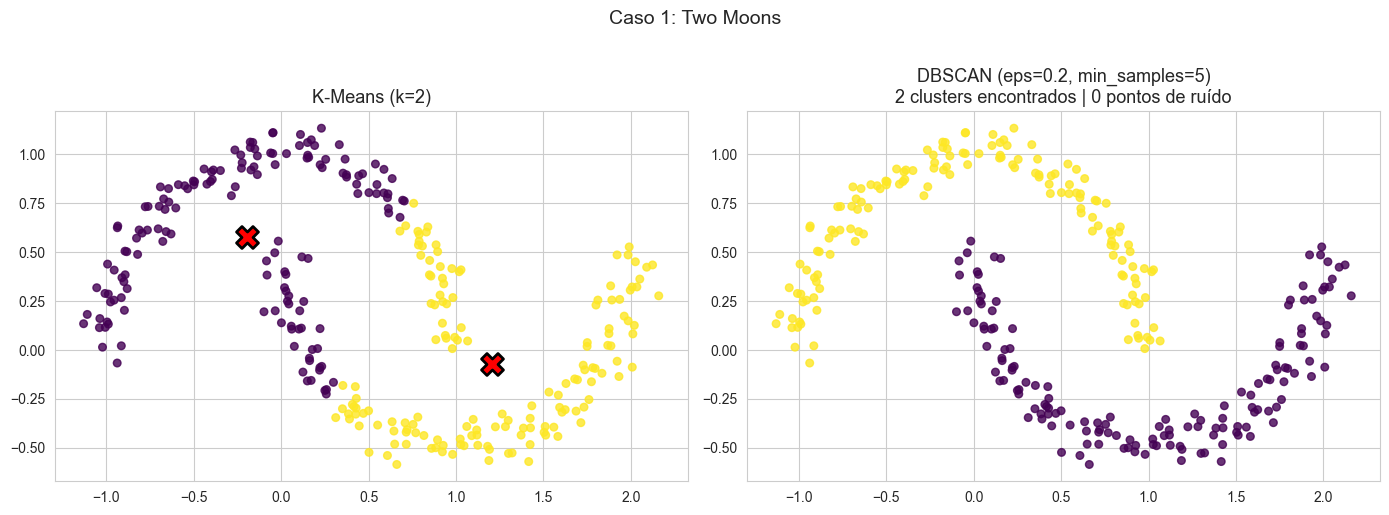

In [105]:
X_moons, _ = make_moons(n_samples=300, noise=0.06, random_state=RANDOM_STATE)
comparar(X_moons, "Caso 1: Two Moons", k=2, eps=0.2, min_samples=5)


👀 **O que aconteceu:**
- **K-Means** cortou as luas no meio porque ele só sabe separar com "linhas retas" (na verdade, hiperplanos).
- **DBSCAN** seguiu o formato natural das luas — ele não se importa com a *forma*, só com a *densidade ao longo* da estrutura.

### Caso 2: Anéis concêntricos ⭕

Um círculo dentro de outro — impossível para o K-Means.

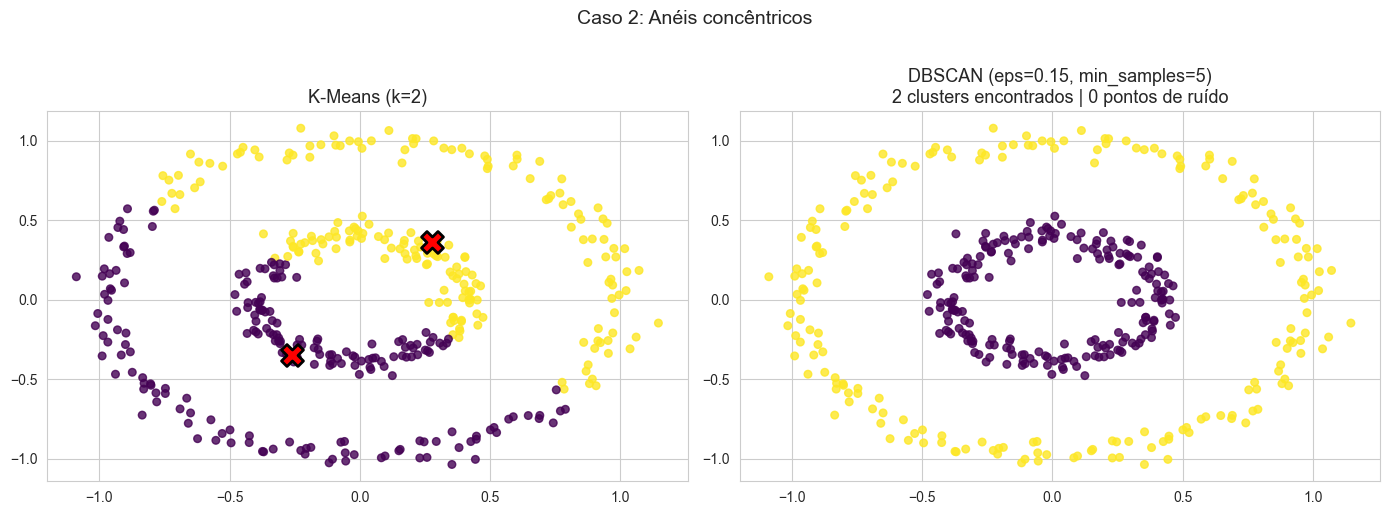

In [106]:
X_circles, _ = make_circles(n_samples=400, noise=0.05, factor=0.4, random_state=RANDOM_STATE)
comparar(X_circles, "Caso 2: Anéis concêntricos", k=2, eps=0.15, min_samples=5)


👀 **K-Means** divide o espaço em "fatias de pizza" — completamente sem sentido para essa estrutura. **DBSCAN** identifica os anéis perfeitamente.

### Caso 3: Clusters + outliers 🎯

Três blobs bem comportados, mas com **pontos de ruído espalhados**. Veremos como cada algoritmo trata os outliers.

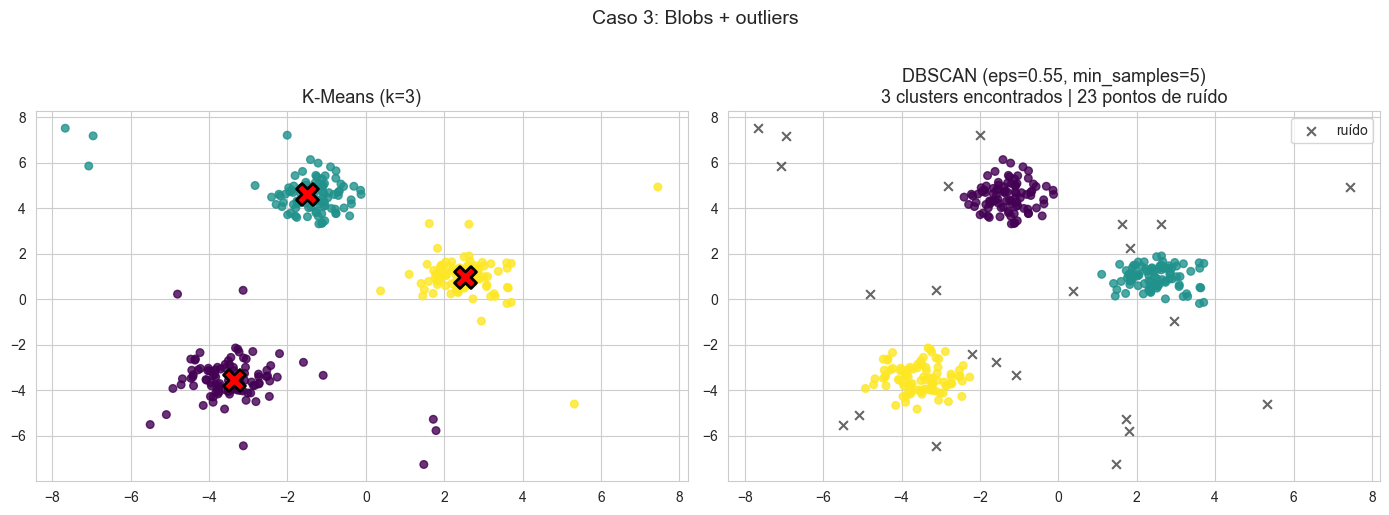

In [107]:
# Três blobs bem definidos
X_blobs, _ = make_blobs(n_samples=280, centers=3, cluster_std=0.6,
                        random_state=RANDOM_STATE, center_box=(-5, 5))

# Adicionamos 20 outliers aleatórios espalhados
outliers = np.random.uniform(-8, 8, size=(20, 2))
X_com_ruido = np.vstack([X_blobs, outliers])

comparar(X_com_ruido, "Caso 3: Blobs + outliers", k=3, eps=0.55, min_samples=5)


👀 **A diferença mais valiosa:**
- **K-Means** *foi obrigado* a colocar cada outlier em algum cluster, distorcendo os centróides.
- **DBSCAN** isolou os outliers como **ruído (rótulo `-1`)**, e os clusters reais ficaram limpos.

> 💡 **Esse é um dos super-poderes do DBSCAN: detecção de anomalias "de graça"**. Útil em fraude, segurança, monitoramento de sistemas, qualquer cenário onde "o que não pertence a nenhum grupo" é interessante.

## 6. Escolhendo `eps`: o gráfico do k-distance

Esse é o passo mais delicado do DBSCAN. Felizmente, existe uma **heurística confiável**: o gráfico do **k-distance**.

### A ideia

Para cada ponto, calcule a **distância até o seu k-ésimo vizinho mais próximo** (onde `k = min_samples`). Depois:

1. **Ordene** essas distâncias em ordem crescente.
2. **Plote** num gráfico.
3. Procure o **"joelho"** — o ponto onde a curva sobe abruptamente.

A intuição: na maioria dos pontos (que estão em regiões densas), o k-ésimo vizinho está perto. Para os outliers, o k-ésimo vizinho está longe. O joelho marca a **transição** entre "denso" e "esparso" — esse é o `eps` ideal.


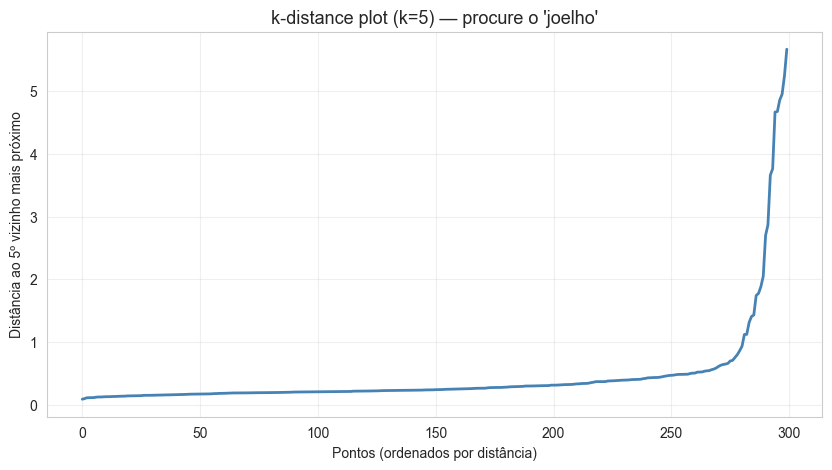

In [108]:
def kdistance_plot(X, k=5):
    """Plota o gráfico do k-distance para ajudar a escolher eps."""
    nn = NearestNeighbors(n_neighbors=k).fit(X)
    distances, _ = nn.kneighbors(X)
    # Pegamos a distância ao k-ésimo vizinho (última coluna) e ordenamos
    k_distances = np.sort(distances[:, -1])

    plt.figure(figsize=(10, 5))
    plt.plot(k_distances, color="steelblue", linewidth=2)
    plt.xlabel("Pontos (ordenados por distância)")
    plt.ylabel(f"Distância ao {k}º vizinho mais próximo")
    plt.title(f"k-distance plot (k={k}) — procure o 'joelho'")
    plt.grid(True, alpha=0.3)
    plt.show()
    return k_distances

# Aplicando aos dados de blobs + outliers
k_dists = kdistance_plot(X_com_ruido, k=5)


👁️ **Como ler o gráfico:**

A maior parte dos pontos tem distância baixa ao 5º vizinho (estão em regiões densas). Lá perto do final, a curva "decola" — esses são os pontos esparsos / outliers.

O **joelho** (onde a curva começa a subir abruptamente) indica o melhor `eps`. Nesse caso, ele está em torno de **0,5 a 0,6** — exatamente o valor que usamos no Caso 3 e que funcionou bem.

> ⚠️ **Cuidado:** essa é uma **heurística visual**, não uma fórmula. Vale experimentar valores ao redor do joelho e ver qual produz resultados que fazem sentido para o problema.

## 7. Como `eps` e `min_samples` afetam o resultado

Nada melhor que ver na prática. Vamos variar os parâmetros num grid e observar.

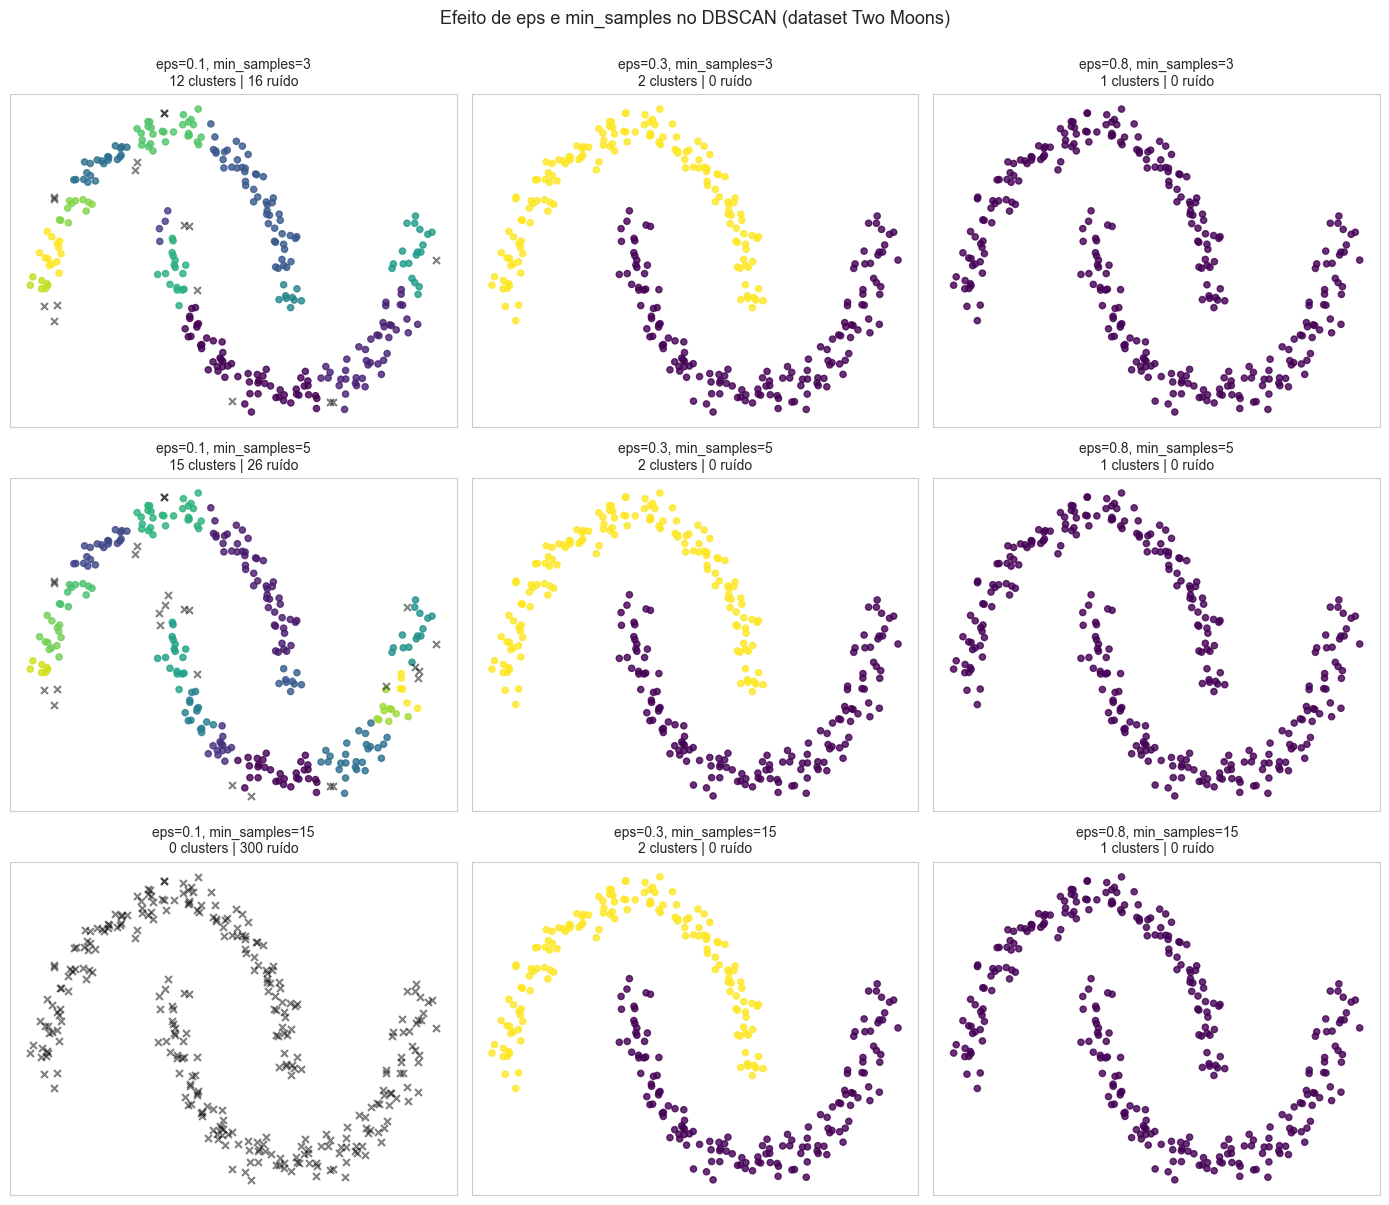

In [109]:
# Grid de experimentos: variando eps e min_samples
fig, axes = plt.subplots(3, 3, figsize=(14, 12))

eps_vals = [0.1, 0.3, 0.8]
min_samples_vals = [3, 5, 15]

for i, ms in enumerate(min_samples_vals):
    for j, e in enumerate(eps_vals):
        db = DBSCAN(eps=e, min_samples=ms).fit(X_moons)
        labels = db.labels_
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_ruido = sum(labels == -1)

        ax = axes[i, j]
        mascara_ruido = labels == -1
        if (~mascara_ruido).any():
            ax.scatter(X_moons[~mascara_ruido, 0], X_moons[~mascara_ruido, 1],
                       c=labels[~mascara_ruido], cmap="viridis", s=20, alpha=0.8)
        if mascara_ruido.any():
            ax.scatter(X_moons[mascara_ruido, 0], X_moons[mascara_ruido, 1],
                       c="black", marker="x", s=25, alpha=0.5)
        ax.set_title(f"eps={e}, min_samples={ms}\n{n_clusters} clusters | {n_ruido} ruído", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("Efeito de eps e min_samples no DBSCAN (dataset Two Moons)", y=1.00, fontsize=13)
plt.tight_layout()
plt.show()


📊 **Leitura do grid:**

- **eps muito pequeno (0.1):** quase tudo vira ruído. O algoritmo é exigente demais sobre o que conta como "perto".
- **eps muito grande (0.8):** tudo vira um cluster só. Sem discriminação.
- **eps ideal (0.3) + min_samples ~ 5:** as duas luas aparecem nitidamente.
- **min_samples alto (15):** mais conservador — exige regiões mais densas para formar cluster.

> 🔑 **Resumo prático:** ajuste `min_samples` primeiro (use a regra `≥ n_features + 1`), depois use o k-distance plot para encontrar o `eps`.

## 8. Limitações do DBSCAN (não é bala de prata!)

| Limitação | Descrição |
|---|---|
| **Densidades muito variáveis** | Um único par `(eps, min_samples)` não dá conta de clusters com densidades diferentes |
| **Alta dimensionalidade** | Sofre da "maldição da dimensionalidade" — em muitas dimensões, todas as distâncias ficam parecidas |
| **Sensibilidade a `eps`** | Resultado pode mudar drasticamente com pequenas variações |
| **Não funciona bem com clusters muito próximos** | Se há "pontes" densas entre dois grupos, o DBSCAN funde os dois |
| **Não generaliza para novos pontos** | Diferente do K-Means, não existe `.predict()` natural — você precisa rodar o algoritmo de novo |

### Quando NÃO usar DBSCAN
- Clusters de **densidades muito diferentes** → considere **HDBSCAN** (versão hierárquica).
- Dados de **alta dimensão** sem redução prévia.
- Você precisa de um modelo para **classificar pontos futuros** (use K-Means ou treine um classificador supervisionado em cima dos rótulos do DBSCAN).

### Comparativo K-Means vs DBSCAN

| Aspecto | K-Means | DBSCAN |
|---|---|---|
| Forma dos clusters | Esférica/convexa | Qualquer formato |
| Precisa de `k`? | Sim | Não |
| Detecta outliers? | Não | **Sim** ⭐ |
| Hiperparâmetros | `k` | `eps`, `min_samples` |
| Velocidade | Muito rápido | Mais lento (O(n log n) com índice) |
| Escala para muitos dados | Excelente | Bom até ~milhões de pontos |
| Sensível a escala das features? | Sim (padronize) | Sim (padronize) |
| Pode prever novos pontos? | Sim (`.predict`) | Não (nativamente) |
| Robusto a outliers? | Não | **Sim** ⭐ |


## 9. Pré-processamento: a regra continua valendo

Como o DBSCAN usa **distância** (assim como o K-Means), **a padronização continua sendo essencial**. Se uma feature varia de 0 a 1 e outra de 0 a 100.000, o `eps` fica impossível de calibrar — qual o raio "certo" num espaço tão distorcido?

> 📌 **Regra de ouro (de novo):** sempre aplique `StandardScaler` antes de rodar DBSCAN, a menos que você tenha um motivo muito específico para não fazer.

Uma alternativa, em alguns problemas, é o **`MinMaxScaler`** (escala todas as features para [0, 1]). Vale para quando as features têm interpretação de "proporção".


---

# 🧪 Laboratório guiado: Detecção de zonas urbanas e outliers geoespaciais

## Contexto de negócio

Você é cientista de dados de um aplicativo de **mobilidade urbana** (algo como Uber/99). Tem um dataset com **localizações de início de corrida** numa cidade, e quer:

1. **Identificar as principais zonas de demanda** (centros, bairros movimentados) — sem saber quantos existem.
2. **Encontrar corridas isoladas** que podem ser:
   - Erros de GPS
   - Corridas em zonas rurais raramente atendidas
   - Eventos pontuais (festivais, shows)

**Por que DBSCAN é perfeito aqui:**
- Bairros têm **formato irregular** (não são círculos perfeitos) → K-Means falharia.
- Não sabemos **quantas zonas** existem a priori.
- **Outliers importam** — queremos identificá-los, não escondê-los num cluster.


## 10.1 Gerando o dataset

Vamos simular pontos de corridas com algumas zonas densas (centros, bairros), uma "rua comercial" alongada, e outliers espalhados pela cidade.

In [110]:
np.random.seed(RANDOM_STATE)

# Zona 1: Centro financeiro (denso, circular)
centro = np.random.normal(loc=[2, 2], scale=0.3, size=(300, 2))

# Zona 2: Bairro residencial movimentado
bairro_norte = np.random.normal(loc=[-2, 3], scale=0.4, size=(200, 2))

# Zona 3: Universidade (cluster denso e pequeno)
universidade = np.random.normal(loc=[3, -2], scale=0.25, size=(150, 2))

# Zona 4: Avenida comercial (formato ALONGADO — K-Means odeia isso)
t = np.linspace(0, 1, 180)
avenida_x = -3 + 5 * t + np.random.normal(0, 0.15, 180)
avenida_y = -2 - 2 * t + np.random.normal(0, 0.15, 180)
avenida = np.column_stack([avenida_x, avenida_y])

# Outliers: corridas isoladas pela cidade
outliers_geo = np.random.uniform(-5, 5, size=(40, 2))

# Combinando
corridas = np.vstack([centro, bairro_norte, universidade, avenida, outliers_geo])

# Criar dataframe para fica mais profissional
df_corridas = pd.DataFrame(corridas, columns=["longitude", "latitude"])
df_corridas["corrida_id"] = range(1, len(df_corridas) + 1)

print(f"📍 Total de corridas: {len(df_corridas)}")
df_corridas.head()


📍 Total de corridas: 870


,longitude,latitude,corrida_id
0,2.149014,1.958521,1
1,2.194307,2.456909,2
2,1.929754,1.929759,3
3,2.473764,2.230230,4
4,1.859158,2.162768,5


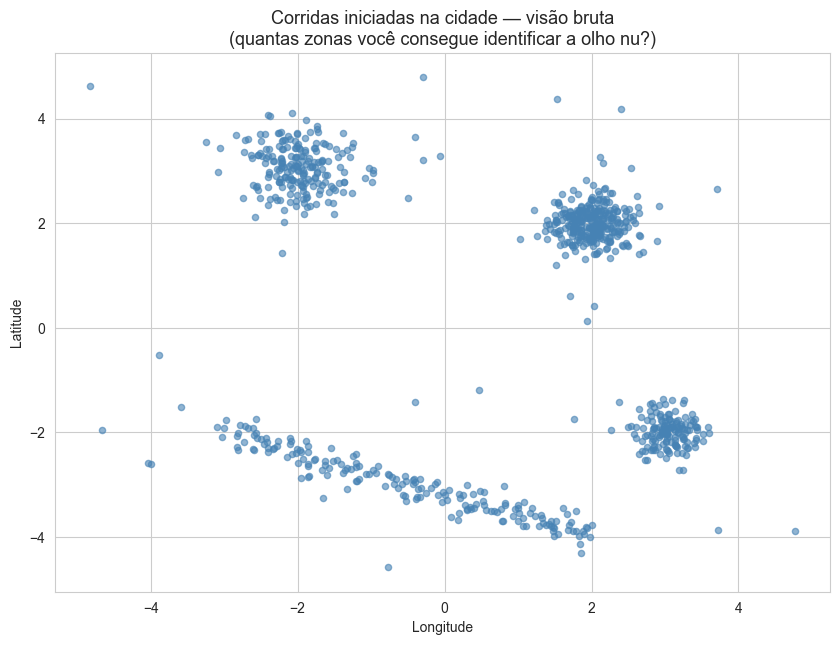

In [111]:
# Visualização inicial — sem rótulos, é assim que recebemos os dados na vida real
plt.figure(figsize=(10, 7))
plt.scatter(df_corridas["longitude"], df_corridas["latitude"],
            s=20, alpha=0.6, color="steelblue")
plt.title("Corridas iniciadas na cidade — visão bruta\n(quantas zonas você consegue identificar a olho nu?)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


👀 A olho nu, dá para perceber algumas regiões densas e pontos espalhados. Vamos ver o que cada algoritmo enxerga.

## 10.2 Primeira tentativa: K-Means (para mostrar o problema)

Vamos rodar K-Means com `k=4` (o número "certo" de zonas).

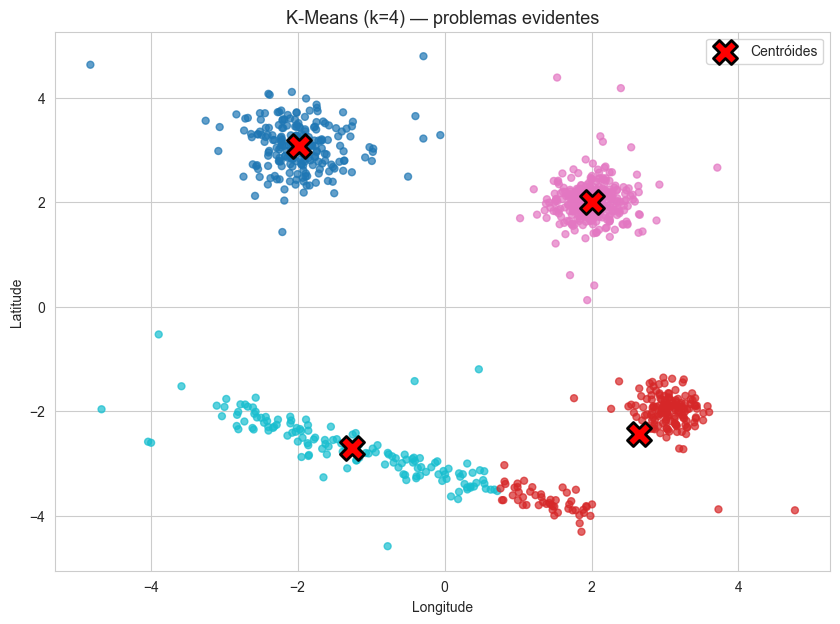

In [112]:
X_lab = df_corridas[["longitude", "latitude"]].values

# Padronizar (boa prática)
scaler = StandardScaler()
X_lab_scaled = scaler.fit_transform(X_lab)

# K-Means com k=4
km_lab = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit(X_lab_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(df_corridas["longitude"], df_corridas["latitude"],
            c=km_lab.labels_, cmap="tab10", s=25, alpha=0.7)
# Centróides no espaço original (precisa desfazer a padronização)
centroids_originais = scaler.inverse_transform(km_lab.cluster_centers_)
plt.scatter(centroids_originais[:, 0], centroids_originais[:, 1],
            c="red", marker="X", s=300, edgecolor="black", linewidth=2,
            label="Centróides")
plt.title("K-Means (k=4) — problemas evidentes")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()


😬 **Problemas do K-Means aqui:**
1. A **avenida comercial** foi *cortada* em dois clusters porque é alongada (K-Means não gosta de formas não-esféricas).
2. Os **outliers** foram *forçados* a entrar em clusters próximos — perdemos a informação valiosa de "essas corridas são suspeitas/raras".
3. Os centróides ficaram em **posições estranhas**, puxados pela mistura.

Vamos ver o DBSCAN.

## 10.3 Escolhendo `eps` com k-distance plot

Antes de rodar DBSCAN, vamos escolher `eps` de forma informada.

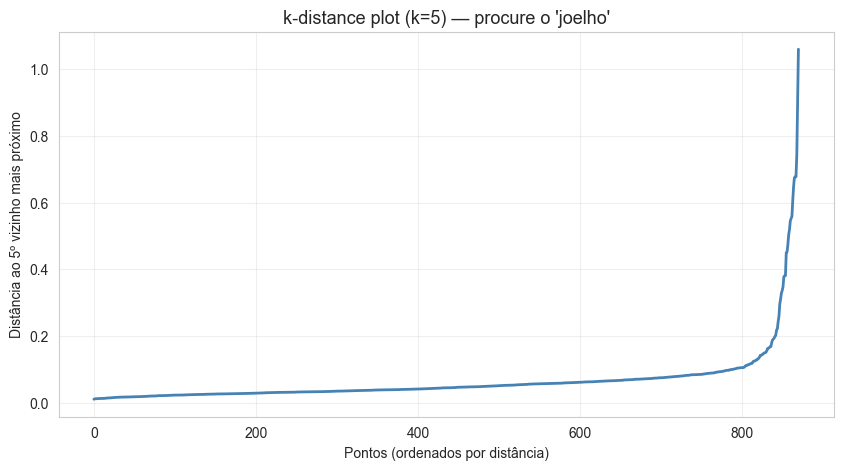

In [113]:
# Para dados 2D, usamos min_samples = 5 (regra prática: >= n_features + 1, mas com folga)
MIN_SAMPLES = 5

k_dists_lab = kdistance_plot(X_lab_scaled, k=MIN_SAMPLES)


**Analisando o joelho:** a curva fica relativamente plana até subir abruptamente lá perto do final. O joelho parece estar entre **0,15 e 0,25**. Vamos testar.

## 10.4 Aplicando DBSCAN

In [114]:
EPS_ESCOLHIDO = 0.18

dbscan_lab = DBSCAN(eps=EPS_ESCOLHIDO, min_samples=MIN_SAMPLES).fit(X_lab_scaled)
df_corridas["cluster"] = dbscan_lab.labels_

# Estatísticas
n_clusters = len(set(dbscan_lab.labels_)) - (1 if -1 in dbscan_lab.labels_ else 0)
n_ruido = sum(dbscan_lab.labels_ == -1)
pct_ruido = 100 * n_ruido / len(df_corridas)

print(f"📊 Resultado do DBSCAN:")
print(f"   • Clusters encontrados: {n_clusters}")
print(f"   • Pontos de ruído (outliers): {n_ruido}  ({pct_ruido:.1f}%)")
print(f"\nDistribuição:")
print(df_corridas["cluster"].value_counts().sort_index())


📊 Resultado do DBSCAN:
   • Clusters encontrados: 4
   • Pontos de ruído (outliers): 27  (3.1%)

Distribuição:
cluster
-1     27
 0    302
 1    205
 2    152
 3    184
Name: count, dtype: int64


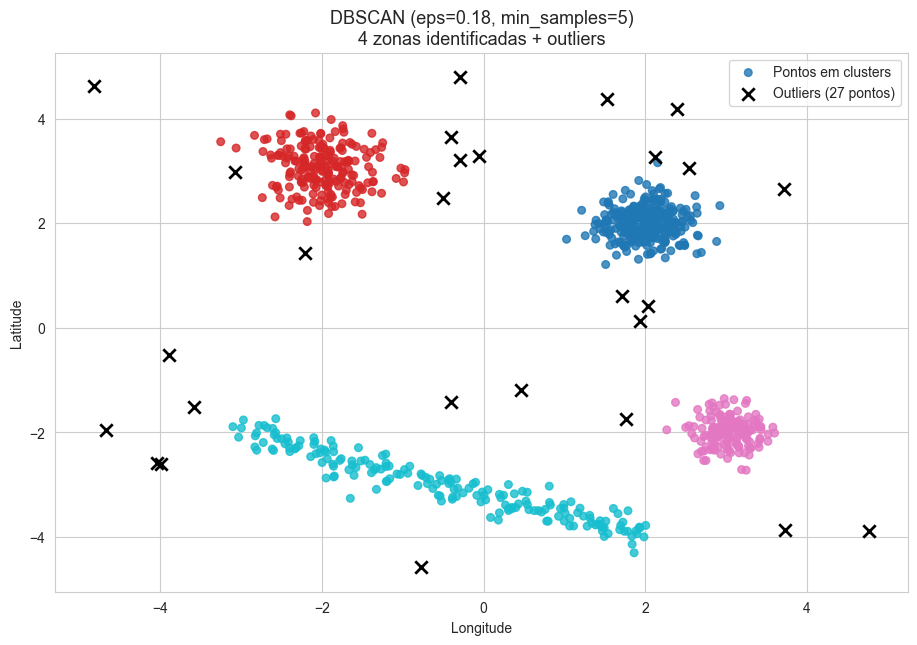

In [115]:
# Visualização: clusters coloridos + ruído destacado
plt.figure(figsize=(11, 7))

mascara_ruido = df_corridas["cluster"] == -1
df_clusters = df_corridas[~mascara_ruido]
df_ruido = df_corridas[mascara_ruido]

# Pontos dos clusters
plt.scatter(df_clusters["longitude"], df_clusters["latitude"],
            c=df_clusters["cluster"], cmap="tab10", s=30, alpha=0.8,
            label="Pontos em clusters")

# Outliers destacados
plt.scatter(df_ruido["longitude"], df_ruido["latitude"],
            c="black", marker="x", s=80, linewidth=2,
            label=f"Outliers ({n_ruido} pontos)")

plt.title(f"DBSCAN (eps={EPS_ESCOLHIDO}, min_samples={MIN_SAMPLES})\n"
          f"{n_clusters} zonas identificadas + outliers")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(loc="upper right")
plt.show()


🎉 **Veja a diferença:**
- A **avenida comercial** foi reconhecida como um cluster único (apesar do formato alongado).
- Os **outliers** foram identificados (marcados com X pretos) — corridas raras que merecem investigação.
- **Não precisamos dizer quantas zonas existem** — o DBSCAN descobriu.

## 10.5 Investigando os outliers

Numa aplicação real, esses pontos seriam **passados para a equipe de operações**. Podem indicar:
- Bugs no GPS
- Eventos especiais (shows, jogos)
- Demanda em zonas mal atendidas (oportunidade de expansão!)


In [116]:
print(f"🚨 Lista de corridas classificadas como outliers:\n")
print(df_ruido[["corrida_id", "longitude", "latitude"]].head(15).to_string(index=False))

if n_ruido > 15:
    print(f"\n... e mais {n_ruido - 15} corridas")


🚨 Lista de corridas classificadas como outliers:

 corrida_id  longitude  latitude
        324  -3.078755  2.978282
        831  -0.288321  3.216369
        832  -0.407348 -1.422017
        833  -0.057876  3.282493
        835   2.120140  3.259782
        836  -3.993625 -2.601259
        837  -3.580280 -1.520586
        838  -0.496490  2.488263
        841  -0.287128  4.791049
        843   1.761776 -1.748960
        847  -2.207239  1.428819
        848   1.941506  0.126548
        850  -4.668106 -1.960536
        851   1.531628  4.383048
        852   3.712045  2.660648

... e mais 12 corridas


## 10.6 Caracterizando cada zona

In [117]:
# Análise de cada zona descoberta
print("📍 Caracterização das zonas (clusters):\n")
for cluster_id in sorted(df_clusters["cluster"].unique()):
    grupo = df_clusters[df_clusters["cluster"] == cluster_id]
    print(f"Zona {cluster_id}:")
    print(f"   • {len(grupo)} corridas")
    print(f"   • Centro aproximado: ({grupo['longitude'].mean():.2f}, {grupo['latitude'].mean():.2f})")
    print(f"   • Extensão: {grupo['longitude'].max()-grupo['longitude'].min():.2f} (long) "
          f"× {grupo['latitude'].max()-grupo['latitude'].min():.2f} (lat)")
    print()


📍 Caracterização das zonas (clusters):

Zona 0:
   • 302 corridas
   • Centro aproximado: (2.00, 1.99)
   • Extensão: 1.90 (long) × 1.95 (lat)

Zona 1:
   • 205 corridas
   • Centro aproximado: (-2.00, 3.06)
   • Extensão: 2.28 (long) × 2.08 (lat)

Zona 2:
   • 152 corridas
   • Centro aproximado: (3.04, -1.99)
   • Extensão: 1.33 (long) × 1.37 (lat)

Zona 3:
   • 184 corridas
   • Centro aproximado: (-0.48, -3.00)
   • Extensão: 5.11 (long) × 2.56 (lat)



📋 **Para o time de negócio:** essas informações alimentam decisões como:
- Onde concentrar motoristas em horários de pico
- Quais bairros têm formato linear (avenidas) vs concentrado (centros)
- Quais áreas com pouca cobertura geram demanda esporádica

## 10.7 Comparação final lado a lado

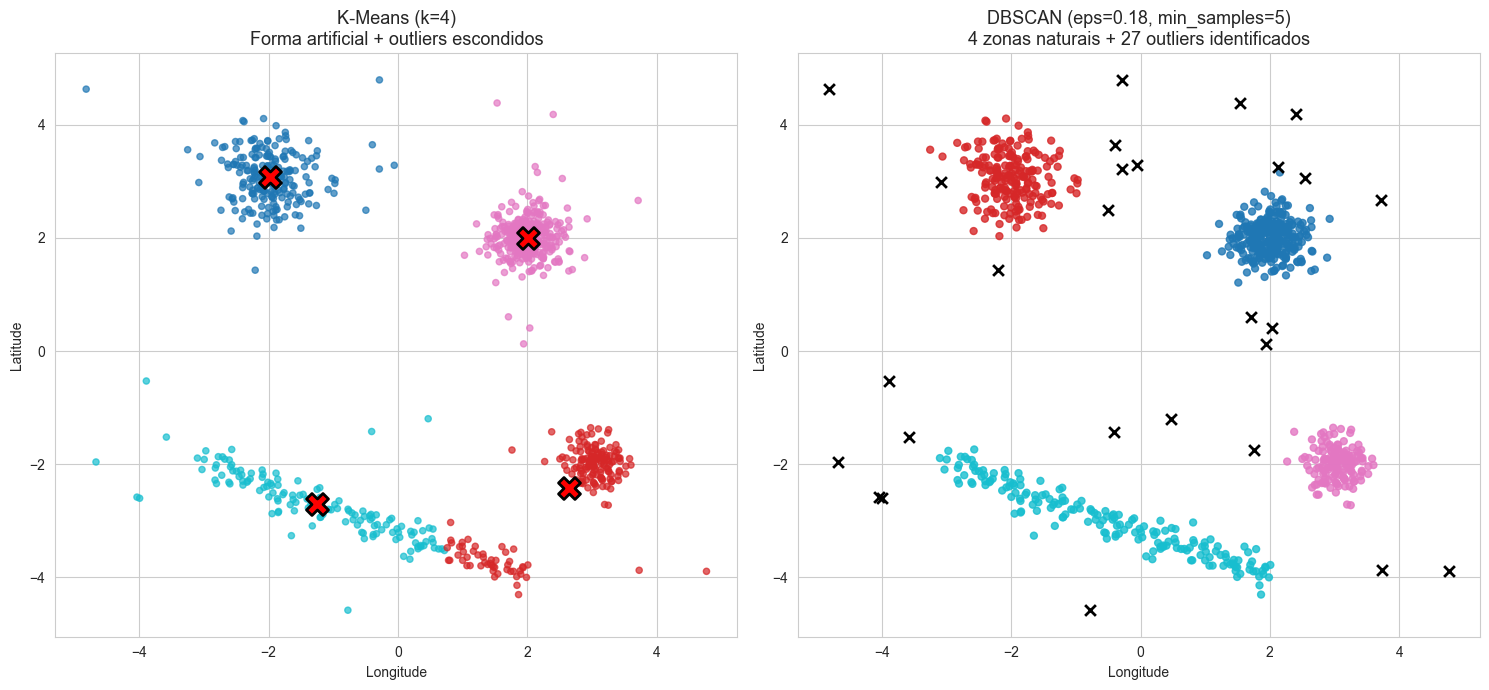

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# K-Means
axes[0].scatter(df_corridas["longitude"], df_corridas["latitude"],
                c=km_lab.labels_, cmap="tab10", s=20, alpha=0.7)
axes[0].scatter(centroids_originais[:, 0], centroids_originais[:, 1],
                c="red", marker="X", s=250, edgecolor="black", linewidth=2)
axes[0].set_title("K-Means (k=4)\nForma artificial + outliers escondidos")

# DBSCAN
axes[1].scatter(df_clusters["longitude"], df_clusters["latitude"],
                c=df_clusters["cluster"], cmap="tab10", s=25, alpha=0.8)
axes[1].scatter(df_ruido["longitude"], df_ruido["latitude"],
                c="black", marker="x", s=60, linewidth=2)
axes[1].set_title(f"DBSCAN (eps={EPS_ESCOLHIDO}, min_samples={MIN_SAMPLES})\n"
                  f"{n_clusters} zonas naturais + {n_ruido} outliers identificados")

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()


## 10.8 Uma ressalva honesta: e se quiséssemos classificar uma nova corrida?

Lembra que mencionei como limitação: o DBSCAN **não tem `.predict()` nativo**. Se chegasse uma corrida nova, como saberíamos a que zona ela pertence?

Algumas estratégias práticas:

1. **Re-rodar DBSCAN** com o ponto novo incluso (custo: rodar tudo de novo).
2. **Atribuir ao cluster do vizinho mais próximo** (rápido, mas perde a noção de densidade).
3. **Treinar um classificador supervisionado** (ex: KNN, Random Forest) usando os rótulos do DBSCAN como `y`. Aí você tem um modelo que prevê zona para qualquer novo ponto.

A estratégia 3 é o padrão da indústria quando você precisa de inferência rápida em produção.

In [119]:
# Exemplo da estratégia 3: usando KNN para "memorizar" os clusters do DBSCAN
from sklearn.neighbors import KNeighborsClassifier

# Treinamos APENAS nos pontos que não são ruído
nao_ruido = df_corridas["cluster"] != -1
X_treino = X_lab_scaled[nao_ruido]
y_treino = df_corridas.loc[nao_ruido, "cluster"].values

knn = KNeighborsClassifier(n_neighbors=5).fit(X_treino, y_treino)

# Função para classificar uma corrida nova
def classificar_corrida(longitude, latitude):
    ponto = scaler.transform([[longitude, latitude]])
    zona = int(knn.predict(ponto)[0])
    # Calcular distância ao vizinho mais próximo do cluster previsto
    # Se for muito grande, considerar como outlier
    dists, _ = NearestNeighbors(n_neighbors=1).fit(X_treino).kneighbors(ponto)
    if dists[0][0] > EPS_ESCOLHIDO * 1.5:
        return "Possível outlier"
    return f"Zona {zona}"

# Testando
print(f"Corrida em (2.1, 2.0):  {classificar_corrida(2.1, 2.0)}   ← no centro")
print(f"Corrida em (-2, 3):     {classificar_corrida(-2, 3)}     ← bairro norte")
print(f"Corrida em (4.5, 4.5):  {classificar_corrida(4.5, 4.5)}  ← longe de tudo")


Corrida em (2.1, 2.0):  Zona 0   ← no centro
Corrida em (-2, 3):     Zona 1     ← bairro norte
Corrida em (4.5, 4.5):  Possível outlier  ← longe de tudo


---

## 🎓 Resumo da aula

| Tópico | Mensagem-chave |
|---|---|
| **Ideia central** | Cluster = região densa. Sem centróides, sem `k`. |
| **Tipos de pontos** | Core (núcleo), Border (borda), Noise (ruído `-1`) |
| **Hiperparâmetros** | `eps` (raio) e `min_samples` (mínimo de vizinhos) |
| **Escolha de `eps`** | k-distance plot — encontre o "joelho" |
| **Vantagens vs K-Means** | Formas arbitrárias, detecta outliers, não precisa de `k` |
| **Desvantagens** | Sofre com densidades variáveis, alta dimensão, sem `predict` nativo |
| **Pré-processamento** | **Sempre padronize** (regra continua valendo) |

## 🔄 Quando usar qual?

```
                       ┌─→ Esféricos, sem outliers, k conhecido  → K-Means
                       │
Seu problema é com... ─┼─→ Formato arbitrário, outliers importam → DBSCAN
                       │
                       └─→ Densidades muito variáveis            → HDBSCAN
```

## 📚 Para aprofundar
- **HDBSCAN** — versão hierárquica do DBSCAN, lida com densidades variáveis e tem `approximate_predict()`.
- **OPTICS** — primo do DBSCAN que produz uma "ordenação por densidade" e permite extrair clusters em múltiplas escalas.
- **Mean-Shift** — outra abordagem baseada em densidade, mas com janelas deslizantes.

## 🏋️ Exercícios propostos
1. Volte aos **dados de segmentação de clientes da aula passada** (3 features: idade, renda, score) e aplique DBSCAN. Os resultados batem com o K-Means? Onde divergem?
2. **Varie `min_samples`** de 3 a 20 nos dados das corridas, mantendo `eps` fixo. O que muda na quantidade de outliers detectados?
3. **Desafio:** baixe um dataset real geoespacial (ex: localizações de bicicletas compartilhadas, ocorrências policiais) e aplique DBSCAN para identificar zonas quentes.
4. **Bônus teórico:** explique por que o DBSCAN é **determinístico** quanto aos clusters formados (dado o mesmo `eps` e `min_samples`), mas a atribuição de **border points** pode variar dependendo da ordem de processamento.

---

🎉 **Boa aula!**


In [120]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import StandardScaler

In [121]:
# Vamos criar um dataset realista com 5 perfis distintos

np.random.seed(42)

def gerar_perfil(n, idade_m, idade_s, renda_m, renda_s, score_m, score_s):
    return pd.DataFrame({
        "Idade":           np.random.normal(idade_m,  idade_s, n).clip(18, 75).astype(int),
        "Renda_Anual_kUSD": np.random.normal(renda_m,  renda_s, n).clip(15, 140).round(1),
        "Score_Gastos":    np.random.normal(score_m, score_s, n).clip(1, 99).astype(int),
    })

# 5 perfis típicos de segmentação de varejo
perfis = [
    gerar_perfil(40, 45, 8,  35,  8,  35, 12),  # Renda baixa, gasto baixo
    gerar_perfil(40, 25, 5,  30,  6,  80,  8),  # Jovem, renda baixa, gasto alto (impulsivos)
    gerar_perfil(40, 50, 10, 90, 12,  20,  9),  # Renda alta, gasto baixo (poupadores)
    gerar_perfil(40, 32, 6,  85, 10,  82,  8),  # Renda alta, gasto alto (alvo premium!)
    gerar_perfil(40, 40, 12, 60,  8,  50, 10),  # Perfil médio
]

clientes = pd.concat(perfis, ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
clientes.insert(0, "ClienteID", range(1, len(clientes) + 1))

print(f"📊 Total de clientes: {len(clientes)}")
clientes.head(10)


📊 Total de clientes: 200


,ClienteID,Idade,Renda_Anual_kUSD,Score_Gastos
0,1,45,81.7,18
1,2,40,42.5,17
2,3,40,37.9,11
3,4,31,68.0,99
4,5,32,86.2,77
5,6,54,90.3,10
6,7,26,20.9,85
7,8,39,65.1,50
8,9,58,54.8,58
9,10,35,32.5,72


In [122]:
features = ["Idade","Renda_Anual_kUSD","Score_Gastos"]

In [123]:
# Selecionar apenas as features numéricas relevantes
X_clientes = clientes[features].values

# Padronizar
scaler = StandardScaler()
X_clientes_scaled = scaler.fit_transform(X_clientes)

# Conferindo: cada feature padronizada tem média ~0 e desvio ~1
df_check = pd.DataFrame(X_clientes_scaled, columns=features)
print("Após padronização:")
print(df_check.describe().round(3).loc[["mean", "std"]])


Após padronização:
      Idade  Renda_Anual_kUSD  Score_Gastos
mean -0.000             0.000         0.000
std   1.003             1.003         1.003


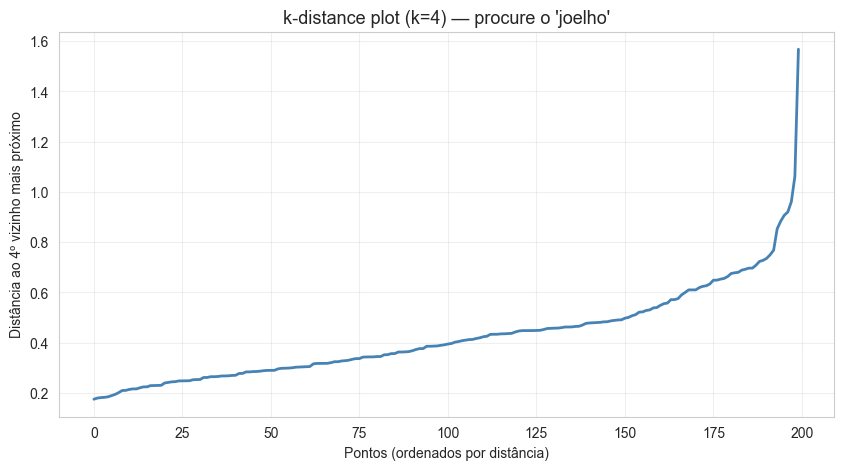

In [124]:
# Para dados 2D, usamos min_samples = 5 (regra prática: >= n_features + 1, mas com folga)
MIN_SAMPLES = 4

k_dists_lab = kdistance_plot(X_clientes_scaled, k=MIN_SAMPLES)


In [125]:
EPS_ESCOLHIDO = 0.7

dbscan_lab = DBSCAN(eps=EPS_ESCOLHIDO, min_samples=MIN_SAMPLES).fit(X_clientes_scaled)
clientes["cluster"] = dbscan_lab.labels_

# Estatísticas
n_clusters = len(set(dbscan_lab.labels_)) - (1 if -1 in dbscan_lab.labels_ else 0)
n_ruido = sum(dbscan_lab.labels_ == -1)
pct_ruido = 100 * n_ruido / len(clientes)

print(f"📊 Resultado do DBSCAN:")
print(f"   • Clusters encontrados: {n_clusters}")
print(f"   • Pontos de ruído (outliers): {n_ruido}  ({pct_ruido:.1f}%)")
print(f"\nDistribuição:")
print(clientes["cluster"].value_counts().sort_index())

📊 Resultado do DBSCAN:
   • Clusters encontrados: 3
   • Pontos de ruído (outliers): 3  (1.5%)

Distribuição:
cluster
-1      3
 0     39
 1    152
 2      6
Name: count, dtype: int64


In [126]:
features

['Idade', 'Renda_Anual_kUSD', 'Score_Gastos']

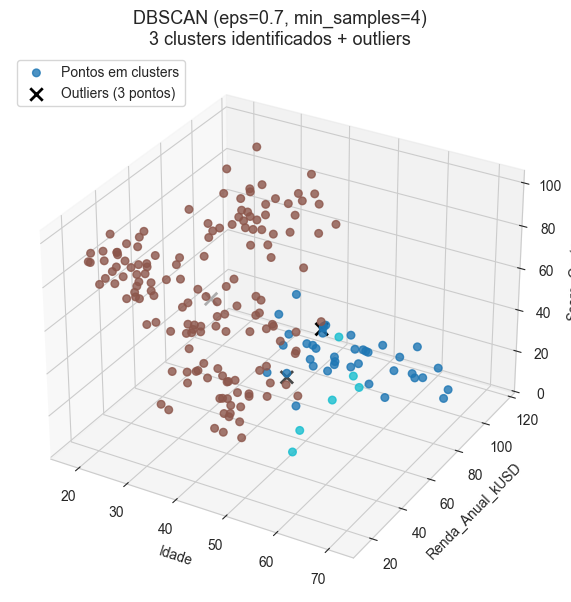

In [127]:
from mpl_toolkits.mplot3d import Axes3D

mascara_ruido = clientes["cluster"] == -1
df_clusters = clientes[~mascara_ruido]
df_ruido = clientes[mascara_ruido]

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")

# Pontos dos clusters
ax.scatter(df_clusters["Idade"], df_clusters["Renda_Anual_kUSD"], df_clusters["Score_Gastos"],
           c=df_clusters["cluster"], cmap="tab10", s=30, alpha=0.8,
           label="Pontos em clusters")

# Outliers destacados
ax.scatter(df_ruido["Idade"], df_ruido["Renda_Anual_kUSD"], df_ruido["Score_Gastos"],
           c="black", marker="x", s=80, linewidth=2,
           label=f"Outliers ({n_ruido} pontos)")

ax.set_title(f"DBSCAN (eps={EPS_ESCOLHIDO}, min_samples={MIN_SAMPLES})\n"
             f"{n_clusters} clusters identificados + outliers")
ax.set_xlabel("Idade")
ax.set_ylabel("Renda_Anual_kUSD")
ax.set_zlabel("Score_Gastos")
ax.legend(loc="upper left")
plt.show()

---
# 🏋️ Exercícios

## Exercício 1 – DBSCAN vs K-Means na segmentação de clientes

Já aplicamos DBSCAN nos dados de clientes (Idade, Renda, Score_Gastos). Agora vamos **comparar com o K-Means** usando o mesmo número de clusters que o DBSCAN encontrou — gráfico 3D lado a lado.

Observe: o K-Means força todos os pontos em algum cluster (até os outliers). O DBSCAN os isola com rótulo `-1`.

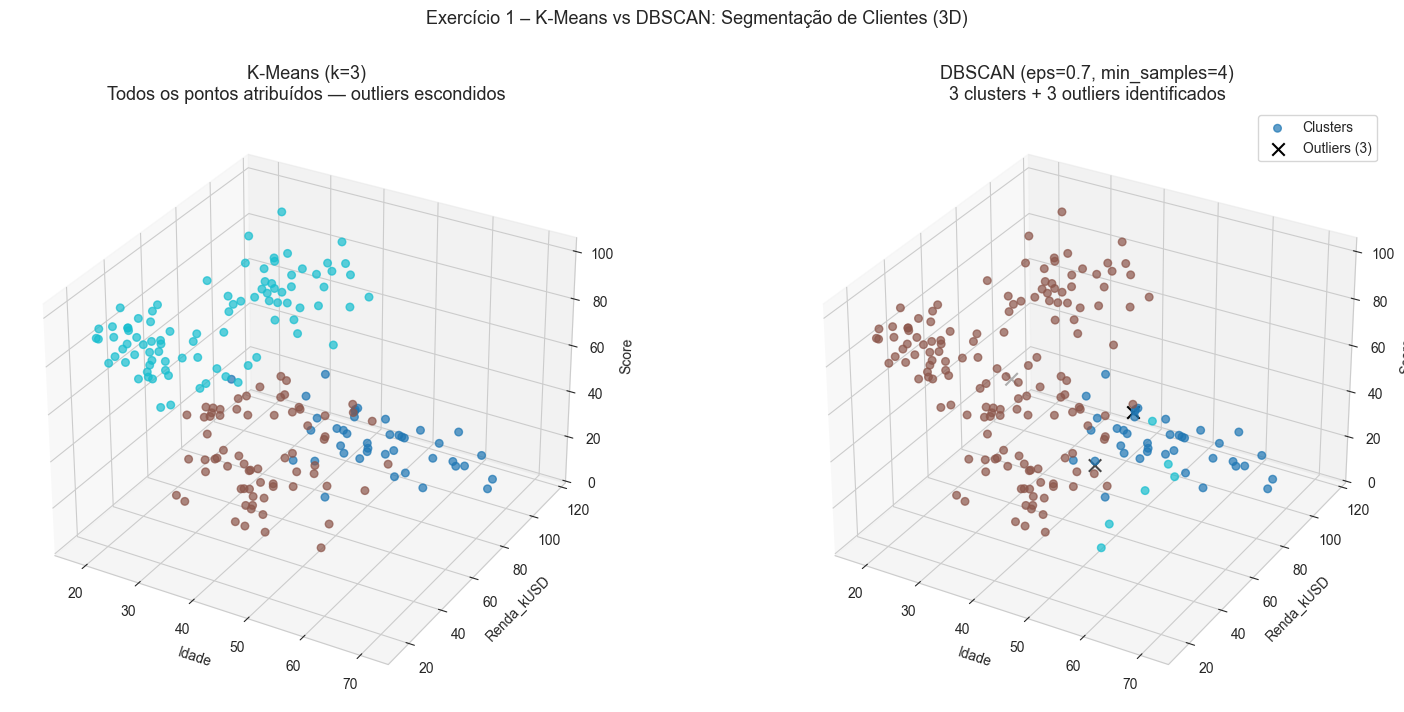

K-Means — distribuição por cluster:
0    41
1    69
2    90

DBSCAN — distribuição por cluster (−1 = outliers):
cluster
-1      3
 0     39
 1    152
 2      6


In [128]:
# Exercício 1 – K-Means vs DBSCAN nos dados de clientes (visualização 3D comparativa)
km_cl = KMeans(n_clusters=n_clusters, n_init=10, random_state=RANDOM_STATE).fit(X_clientes_scaled)

fig = plt.figure(figsize=(16, 7))

# K-Means
ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(clientes["Idade"], clientes["Renda_Anual_kUSD"], clientes["Score_Gastos"],
            c=km_cl.labels_, cmap="tab10", s=30, alpha=0.7)
ax1.set_title(f"K-Means (k={n_clusters})\nTodos os pontos atribuídos — outliers escondidos")
ax1.set_xlabel("Idade")
ax1.set_ylabel("Renda_kUSD")
ax1.set_zlabel("Score")

# DBSCAN
ax2 = fig.add_subplot(122, projection="3d")
mascara_ruido_ex1 = clientes["cluster"] == -1
df_cl_ex1 = clientes[~mascara_ruido_ex1]
df_ru_ex1 = clientes[mascara_ruido_ex1]
ax2.scatter(df_cl_ex1["Idade"], df_cl_ex1["Renda_Anual_kUSD"], df_cl_ex1["Score_Gastos"],
            c=df_cl_ex1["cluster"], cmap="tab10", s=30, alpha=0.7, label="Clusters")
ax2.scatter(df_ru_ex1["Idade"], df_ru_ex1["Renda_Anual_kUSD"], df_ru_ex1["Score_Gastos"],
            c="black", marker="x", s=80, label=f"Outliers ({n_ruido})")
ax2.set_title(f"DBSCAN (eps={EPS_ESCOLHIDO}, min_samples={MIN_SAMPLES})\n{n_clusters} clusters + {n_ruido} outliers identificados")
ax2.set_xlabel("Idade")
ax2.set_ylabel("Renda_kUSD")
ax2.set_zlabel("Score")
ax2.legend()

plt.suptitle("Exercício 1 – K-Means vs DBSCAN: Segmentação de Clientes (3D)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("K-Means — distribuição por cluster:")
print(pd.Series(km_cl.labels_).value_counts().sort_index().rename("quantidade").to_string())
print("\nDBSCAN — distribuição por cluster (−1 = outliers):")
print(clientes["cluster"].value_counts().sort_index().rename("quantidade").to_string())

## Exercício 2 – Variando `min_samples` nos dados das corridas

Mantemos `eps = 0.18` (valor escolhido pelo joelho do k-distance plot) e variamos `min_samples` de **3 a 20**.

Observe como a quantidade de outliers e clusters responde a essa variação: `min_samples` alto exige regiões mais densas, tornando o algoritmo mais conservador — mais pontos passam a ser ruído.

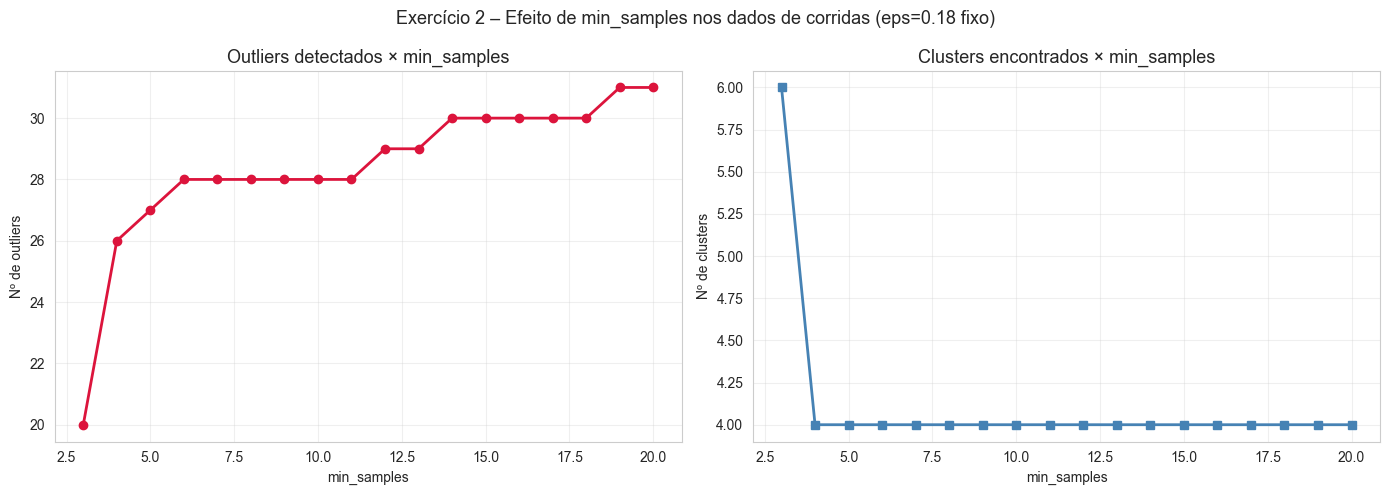


 min_samples | clusters | outliers
------------------------------------
           3 |        6 |       20
           4 |        4 |       26
           5 |        4 |       27
           6 |        4 |       28
           7 |        4 |       28
           8 |        4 |       28
           9 |        4 |       28
          10 |        4 |       28
          11 |        4 |       28
          12 |        4 |       29
          13 |        4 |       29
          14 |        4 |       30
          15 |        4 |       30
          16 |        4 |       30
          17 |        4 |       30
          18 |        4 |       30
          19 |        4 |       31
          20 |        4 |       31


In [129]:
# Exercício 2 – Variar min_samples de 3 a 20 nos dados das corridas (eps = 0.18 fixo)
eps_fixo_corridas = 0.18
ms_vals = list(range(3, 21))
n_outliers_por_ms = []
n_clusters_por_ms = []

for ms in ms_vals:
    db = DBSCAN(eps=eps_fixo_corridas, min_samples=ms).fit(X_lab_scaled)
    labels = db.labels_
    n_outliers_por_ms.append((labels == -1).sum())
    n_clusters_por_ms.append(len(set(labels)) - (1 if -1 in labels else 0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ms_vals, n_outliers_por_ms, marker="o", color="crimson", linewidth=2)
axes[0].set_xlabel("min_samples")
axes[0].set_ylabel("Nº de outliers")
axes[0].set_title("Outliers detectados × min_samples")
axes[0].grid(True, alpha=0.3)

axes[1].plot(ms_vals, n_clusters_por_ms, marker="s", color="steelblue", linewidth=2)
axes[1].set_xlabel("min_samples")
axes[1].set_ylabel("Nº de clusters")
axes[1].set_title("Clusters encontrados × min_samples")
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"Exercício 2 – Efeito de min_samples nos dados de corridas (eps={eps_fixo_corridas} fixo)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n{'min_samples':>12} | {'clusters':>8} | {'outliers':>8}")
print("-" * 36)
for ms, nc, no in zip(ms_vals, n_clusters_por_ms, n_outliers_por_ms):
    print(f"{ms:>12} | {nc:>8} | {no:>8}")

## Exercício 3 – Dataset geoespacial real

Usaremos as **coordenadas geográficas (latitude/longitude)** do dataset **California Housing** do scikit-learn — um conjunto com ~20.000 registros de imóveis na Califórnia.

O objetivo é identificar **regiões de alta densidade urbana** (Los Angeles, São Francisco, San Diego, Sacramento...) como clusters, e isolar locais esparsos como outliers.

> Esse dataset já vem embutido no scikit-learn — não precisa de download externo.

k-distance plot:


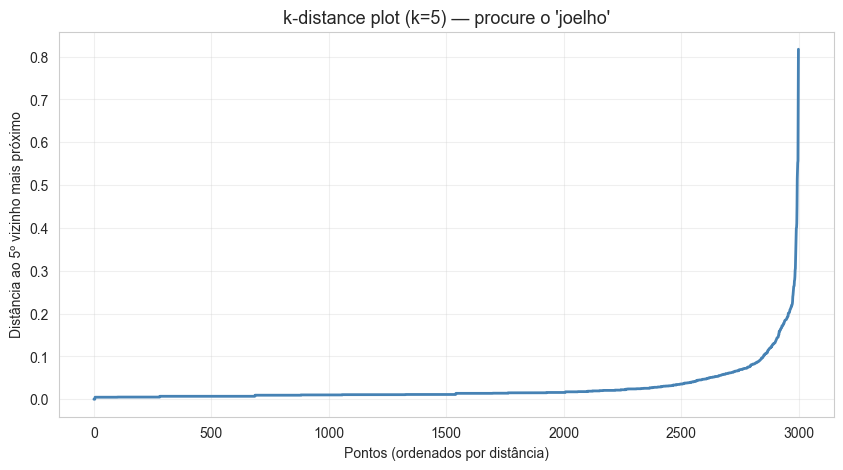


📊 7 regiões identificadas | 72 outliers (2.4%)


In [131]:
# Exercício 3 – Dataset geoespacial real: California Housing (lat/lon de ~20k imóveis)
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
df_cal = pd.DataFrame(housing.data, columns=housing.feature_names)[["Latitude", "Longitude"]]
df_cal_sample = df_cal.sample(3000, random_state=RANDOM_STATE).reset_index(drop=True)

scaler_cal = StandardScaler()
X_cal = scaler_cal.fit_transform(df_cal_sample)

# k-distance para escolher eps
print("k-distance plot:")
kdistance_plot(X_cal, k=5)

# Aplicar DBSCAN
db_cal = DBSCAN(eps=0.15, min_samples=5).fit(X_cal)
df_cal_sample["cluster"] = db_cal.labels_

n_cl_cal = len(set(db_cal.labels_)) - (1 if -1 in db_cal.labels_ else 0)
n_ru_cal = (db_cal.labels_ == -1).sum()
print(f"\n📊 {n_cl_cal} regiões identificadas | {n_ru_cal} outliers ({100*n_ru_cal/len(df_cal_sample):.1f}%)")



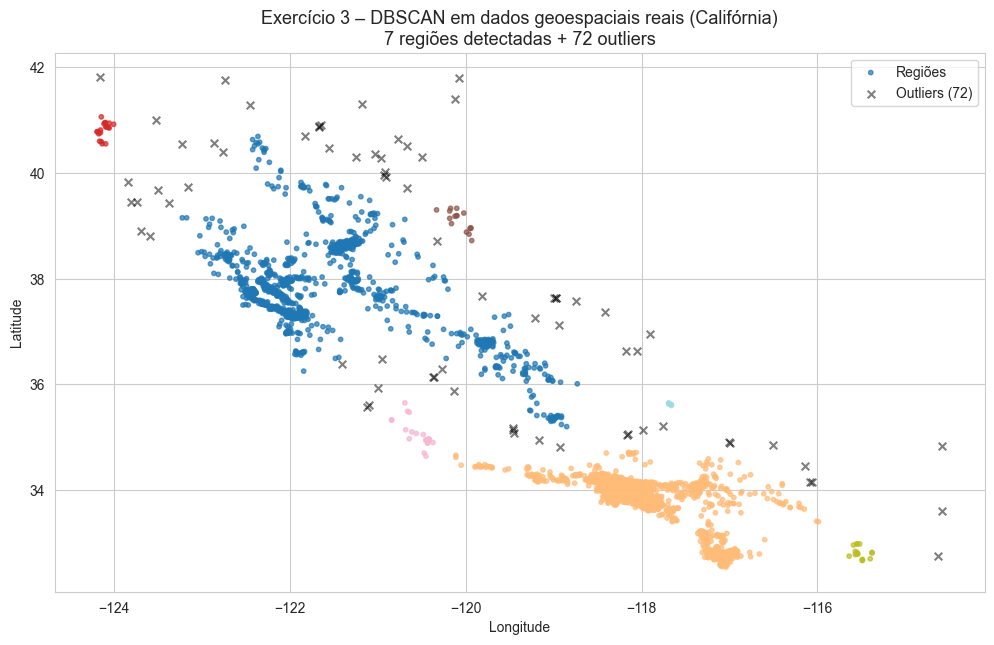

In [132]:
# Visualização
plt.figure(figsize=(12, 7))
mascara_cal = df_cal_sample["cluster"] == -1
plt.scatter(df_cal_sample.loc[~mascara_cal, "Longitude"],
            df_cal_sample.loc[~mascara_cal, "Latitude"],
            c=df_cal_sample.loc[~mascara_cal, "cluster"],
            cmap="tab20", s=10, alpha=0.7, label="Regiões")
plt.scatter(df_cal_sample.loc[mascara_cal, "Longitude"],
            df_cal_sample.loc[mascara_cal, "Latitude"],
            c="black", marker="x", s=30, alpha=0.5, label=f"Outliers ({n_ru_cal})")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Exercício 3 – DBSCAN em dados geoespaciais reais (Califórnia)\n{n_cl_cal} regiões detectadas + {n_ru_cal} outliers")
plt.legend()
plt.show()

## Exercício 4 – Por que o DBSCAN é determinístico nos clusters, mas não nos border points?

Em computação e em algoritmos, ser determinístico significa que, ao executar o processo várias vezes com os mesmos dados e configurações, o resultado será sempre o mesmo. No caso do DBSCAN, isso quer dizer que usando o mesmo conjunto de dados, o mesmo valor de epsilon e MinPts, os clusters principais formados pelo algoritmo não mudam entre as execuções.
